In [ ]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [2]:
paired_df = pd.read_csv("model_data/adni/paired_df_full.csv", index_col=0)

In [3]:
paired_df['group'].value_counts()

group
CN      109
MCI      52
EMCI     28
LMCI      9
SMC       8
AD        6
Name: count, dtype: int64

In [4]:
# Directories
dti_reg_dir = Path("model_data/adni/dti_registered")
t1_reg_dir = Path("model_data/adni/t1_registered")

In [5]:
# Load GM and WM masks
gm_mask = nib.load("model_data/mni_gm_mask.nii")
wm_mask = nib.load("model_data/mni_wm_mask.nii")

In [6]:
example_img = nib.load("model_data/adni/dti_registered/I820310_016_S_4951.nii")

FileNotFoundError: No such file or no access: 'model_data/adni/dti_registered/I820310_016_S_4951.nii'

In [ ]:
gm_mask_resampled = nilearn.image.resample_to_img(gm_mask, example_img, interpolation="continuous")
wm_mask_resampled = nilearn.image.resample_to_img(wm_mask, example_img, interpolation="continuous")

/var/folders/4r/2w_vg8k91mldqsvxyw1y1cnml0bjbd/T/ipykernel_59870/3567376117.py:1: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  gm_mask_resampled = nilearn.image.resample_to_img(gm_mask, example_img, interpolation="continuous")
/var/folders/4r/2w_vg8k91mldqsvxyw1y1cnml0bjbd/T/ipykernel_59870/3567376117.py:2: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  wm_mask_resampled = nilearn.image.resample_to_img(wm_mask, example_img, interpolation="continuous")


In [ ]:
gm_mask_resampled = gm_mask_resampled.get_fdata()
wm_mask_resampled = wm_mask_resampled.get_fdata()

In [ ]:
# Initialize lists for dataframes
dti_wm_data = []
dti_gm_data = []
t1_wm_data = []
t1_gm_data = []

In [ ]:
# Process DTI images with WM mask
for dti_file in tqdm(sorted(dti_reg_dir.glob("*.nii")), desc="DTI WM"):
    try:
        dti_img = nib.load(str(dti_file))
        dti_data = dti_img.get_fdata()
        
        # Apply WM mask
        masked_data = dti_data * wm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        dti_wm_data.append({
            'file_name': dti_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {dti_file.name}: {e}")

DTI WM: 100%|██████████| 212/212 [00:04<00:00, 43.65it/s]


In [ ]:
# Process DTI images with GM mask
for dti_file in tqdm(sorted(dti_reg_dir.glob("*.nii")), desc="DTI GM"):
    try:
        dti_img = nib.load(str(dti_file))
        dti_data = dti_img.get_fdata()
        
        # Apply GM mask
        masked_data = dti_data * gm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        dti_gm_data.append({
            'file_name': dti_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {dti_file.name}: {e}")

DTI GM: 100%|██████████| 212/212 [00:05<00:00, 39.73it/s]


In [ ]:
# Process T1 images with WM mask
for t1_file in tqdm(sorted(t1_reg_dir.glob("*.nii")), desc="T1 WM"):
    try:
        t1_img = nib.load(str(t1_file))
        t1_data = t1_img.get_fdata()
        
        # Apply WM mask
        masked_data = t1_data * wm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        t1_wm_data.append({
            'file_name': t1_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {t1_file.name}: {e}")

T1 WM: 100%|██████████| 212/212 [00:05<00:00, 42.01it/s]


In [ ]:
# Process T1 images with GM mask
for t1_file in tqdm(sorted(t1_reg_dir.glob("*.nii")), desc="T1 GM"):
    try:
        t1_img = nib.load(str(t1_file))
        t1_data = t1_img.get_fdata()
        
        # Apply GM mask
        masked_data = t1_data * gm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        t1_gm_data.append({
            'file_name': t1_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {t1_file.name}: {e}")

T1 GM: 100%|██████████| 212/212 [00:04<00:00, 45.50it/s]


In [ ]:
dti_masked_wm = pd.DataFrame(dti_wm_data)
dti_masked_gm = pd.DataFrame(dti_gm_data)
t1_masked_wm = pd.DataFrame(t1_wm_data)
t1_masked_gm = pd.DataFrame(t1_gm_data)

In [ ]:
pd.DataFrame.to_parquet(dti_masked_wm, "model_data/adni/dti_masked_wm.parquet")
pd.DataFrame.to_parquet(dti_masked_gm, "model_data/adni/dti_masked_gm.parquet")
pd.DataFrame.to_parquet(t1_masked_wm, "model_data/adni/t1_masked_wm.parquet")
pd.DataFrame.to_parquet(t1_masked_gm, "model_data/adni/t1_masked_gm.parquet")

In [ ]:
dti_masked_wm = pd.read_parquet("model_data/adni/dti_masked_wm.parquet")
dti_masked_gm = pd.read_parquet("model_data/adni/dti_masked_gm.parquet")
t1_masked_wm = pd.read_parquet("model_data/adni/t1_masked_wm.parquet")
t1_masked_gm = pd.read_parquet("model_data/adni/t1_masked_gm.parquet")

In [ ]:
# Write code for dti_masked_wm = dti_masked_wm rows only if the paired_df['dti_file_name']
# is in the dti_masked_wm['file_name']
dti_masked_wm = dti_masked_wm[dti_masked_wm['file_name'].isin(paired_df['dti_file_name'])]
dti_masked_gm = dti_masked_gm[dti_masked_gm['file_name'].isin(paired_df['dti_file_name'])]
t1_masked_wm = t1_masked_wm[t1_masked_wm['file_name'].isin(paired_df['t1_file_name'])]
t1_masked_gm = t1_masked_gm[t1_masked_gm['file_name'].isin(paired_df['t1_file_name'])]

In [ ]:
# Get the first row from dti_masked_wm
file_name = dti_masked_wm.iloc[0]['file_name']
masked_data_flat = dti_masked_wm.iloc[0]['masked_data']

# Load the corresponding registered image to get shape and affine
dti_reg_file = dti_reg_dir / file_name
dti_reg_img = nib.load(str(dti_reg_file))

# Get the shape and affine
original_shape = dti_reg_img.shape
affine = dti_reg_img.affine

# Reshape the flattened masked data back to 3D
masked_data_3d = masked_data_flat.reshape(original_shape)
masked_img = nib.Nifti1Image(masked_data_3d, affine)

# Visualize using nilearn
nilearn.plotting.plot_img(masked_img, title=f"Masked DTI WM: {file_name}", display_mode='ortho', cut_coords=None)

NameError: name 'dti_reg_dir' is not defined

In [ ]:
dti_wm_arrays = [row['masked_data'] for _, row in dti_masked_wm.iterrows()]
dti_gm_arrays = [row['masked_data'] for _, row in dti_masked_gm.iterrows()]
t1_wm_arrays = [row['masked_data'] for _, row in t1_masked_wm.iterrows()]
t1_gm_arrays = [row['masked_data'] for _, row in t1_masked_gm.iterrows()]

# Convert to numpy arrays (samples x features)
dti_wm_matrix = np.array(dti_wm_arrays)
dti_gm_matrix = np.array(dti_gm_arrays)
t1_wm_matrix = np.array(t1_wm_arrays)
t1_gm_matrix = np.array(t1_gm_arrays)

print(f"DTI WM matrix shape: {dti_wm_matrix.shape}")
print(f"DTI GM matrix shape: {dti_gm_matrix.shape}")
print(f"T1 WM matrix shape: {t1_wm_matrix.shape}")
print(f"T1 GM matrix shape: {t1_gm_matrix.shape}")

DTI WM matrix shape: (212, 2122945)
DTI GM matrix shape: (212, 2122945)
T1 WM matrix shape: (212, 2122945)
T1 GM matrix shape: (212, 2122945)


In [ ]:
# Standardize each dataset
scaler_dti_wm = StandardScaler()
scaler_dti_gm = StandardScaler()
scaler_t1_wm = StandardScaler()
scaler_t1_gm = StandardScaler()

dti_wm_scaled = scaler_dti_wm.fit_transform(dti_wm_matrix)
dti_gm_scaled = scaler_dti_gm.fit_transform(dti_gm_matrix)
t1_wm_scaled = scaler_t1_wm.fit_transform(t1_wm_matrix)
t1_gm_scaled = scaler_t1_gm.fit_transform(t1_gm_matrix)

print(f"DTI WM scaled - mean: {dti_wm_scaled.mean():.6f}, std: {dti_wm_scaled.std():.6f}")
print(f"DTI GM scaled - mean: {dti_gm_scaled.mean():.6f}, std: {dti_gm_scaled.std():.6f}")
print(f"T1 WM scaled - mean: {t1_wm_scaled.mean():.6f}, std: {t1_wm_scaled.std():.6f}")
print(f"T1 GM scaled - mean: {t1_gm_scaled.mean():.6f}, std: {t1_gm_scaled.std():.6f}")

DTI WM scaled - mean: 0.000000, std: 0.365384
DTI GM scaled - mean: -0.000000, std: 0.461764
T1 WM scaled - mean: 0.000000, std: 0.365384
T1 GM scaled - mean: 0.000000, std: 0.461764


In [ ]:
# Create and fit 4 PCA models (one for each masked dataset)
pca_dti_wm = PCA(n_components=100)
pca_dti_gm = PCA(n_components=100)
pca_t1_wm = PCA(n_components=100)
pca_t1_gm = PCA(n_components=100)

In [ ]:
# Fit and transform each dataset
dti_wm_pca = pca_dti_wm.fit_transform(dti_wm_scaled)

In [ ]:
dti_gm_pca = pca_dti_gm.fit_transform(dti_gm_scaled)

In [ ]:
t1_wm_pca = pca_t1_wm.fit_transform(t1_wm_scaled)

In [ ]:
t1_gm_pca = pca_t1_gm.fit_transform(t1_gm_scaled)

In [ ]:
amy_data_raw_full = pd.read_csv('model_data/adni/All_Subjects_UCBERKELEY_AMY_6MM_08Feb2026.csv')

In [ ]:
subject_ids = amy_data_raw_full['PTID']
amyloid_status = amy_data_raw_full['AMYLOID_STATUS_COMPOSITE_REF']
subject_dates = amy_data_raw_full['PROCESSDATE']

In [ ]:
def normalize_subject_id(x):
    s = str(x).strip()
    if s.startswith('ADNI_'):
        s = s.replace('ADNI_', '', 1)
    return s

amy_lookup = pd.DataFrame({
    'subject_id': subject_ids.astype(str).map(normalize_subject_id),
    'amy_date': pd.to_datetime(subject_dates, errors='coerce'),
    'amyloid_status': amyloid_status
}).dropna(subset=['subject_id'])

# Parse DTI date strings like 2017-06-21_13_52_49.0 explicitly
paired_df['dti_date_parsed'] = pd.to_datetime(
    paired_df['dti_date_taken'],
    format='%Y-%m-%d_%H_%M_%S.%f',
    errors='coerce'
)

# Fallback parse for any outliers not matching the exact format
missing_mask = paired_df['dti_date_parsed'].isna()
if missing_mask.any():
    paired_df.loc[missing_mask, 'dti_date_parsed'] = pd.to_datetime(
        paired_df.loc[missing_mask, 'dti_date_taken'],
        errors='coerce'
    )

paired_df['subject_id_norm'] = paired_df['subject_id'].astype(str).map(normalize_subject_id)

amy_by_subject = {
    sid: grp.dropna(subset=['amy_date']).copy()
    for sid, grp in amy_lookup.groupby('subject_id', sort=False)
}

In [ ]:
def nearest_amyloid_status(row):
    sid = row['subject_id_norm']
    dti_dt = row['dti_date_parsed']

    if pd.isna(dti_dt) or sid not in amy_by_subject:
        return np.nan

    subject_rows = amy_by_subject[sid]
    if subject_rows.empty:
        return np.nan

    nearest_idx = (subject_rows['amy_date'] - dti_dt).abs().idxmin()
    return subject_rows.loc[nearest_idx, 'amyloid_status']

In [ ]:
paired_df['label_amy'] = paired_df.apply(nearest_amyloid_status, axis=1)

In [ ]:
# Keep only rows with an amyloid label
paired_df_amy = paired_df[paired_df['label_amy'].notna()].copy()

print('Rows in paired_df_amy:', len(paired_df_amy))
print('Unique subjects in paired_df_amy:', paired_df_amy['subject_id'].nunique())

# Ensure label_amy is numeric 0/1 for comparisons
label_amy_num = pd.to_numeric(paired_df_amy['label_amy'], errors='coerce')

count_11 = ((paired_df_amy['label'] == 1) & (label_amy_num == 1)).sum()
count_00 = ((paired_df_amy['label'] == 0) & (label_amy_num == 0)).sum()
count_10 = ((paired_df_amy['label'] == 1) & (label_amy_num == 0)).sum()
count_01 = ((paired_df_amy['label'] == 0) & (label_amy_num == 1)).sum()

print('label=1 and label_amy=1:', count_11)
print('label=0 and label_amy=0:', count_00)
print('label=1 and label_amy=0:', count_10)
print('label=0 and label_amy=1:', count_01)

Rows in paired_df_amy: 200
Unique subjects in paired_df_amy: 117
label=1 and label_amy=1: 32
label=0 and label_amy=0: 94
label=1 and label_amy=0: 56
label=0 and label_amy=1: 18


In [ ]:
valid_groups = {'SMC', 'CN', 'EMCI', 'LMCI', 'MCI', 'AD'}
paired_df['label_short'] = paired_df['group'].apply(
    lambda x: 0 if x in ('SMC', 'CN', 'EMCI') else (1 if x in ('LMCI', 'MCI', 'AD') else 'N/A')
)

In [ ]:
dti_file_to_label = dict(zip(paired_df['dti_file_name'], paired_df['label']))
t1_file_to_label = dict(zip(paired_df['t1_file_name'], paired_df['label']))

dti_masked_wm = dti_masked_wm[dti_masked_wm['file_name'].isin(dti_file_to_label)].copy()
dti_masked_gm = dti_masked_gm[dti_masked_gm['file_name'].isin(dti_file_to_label)].copy()
t1_masked_wm = t1_masked_wm[t1_masked_wm['file_name'].isin(t1_file_to_label)].copy()
t1_masked_gm = t1_masked_gm[t1_masked_gm['file_name'].isin(t1_file_to_label)].copy()

y_dti_wm = [dti_file_to_label[row['file_name']] for _, row in dti_masked_wm.iterrows()]
y_dti_gm = [dti_file_to_label[row['file_name']] for _, row in dti_masked_gm.iterrows()]
y_t1_wm = [t1_file_to_label[row['file_name']] for _, row in t1_masked_wm.iterrows()]
y_t1_gm = [t1_file_to_label[row['file_name']] for _, row in t1_masked_gm.iterrows()]

In [ ]:
# Convert to numpy arrays
y_dti_wm = np.array(y_dti_wm)
y_dti_gm = np.array(y_dti_gm)
y_t1_wm = np.array(y_t1_wm)
y_t1_gm = np.array(y_t1_gm)

In [ ]:
# Train-test split for all 4 datasets (using same random_state for reproducibility)
# Split each dataset independently but with same random_state to ensure consistent splits
X_dti_wm_train, X_dti_wm_test, y_dti_wm_train, y_dti_wm_test = train_test_split(
    dti_wm_pca, y_dti_wm, test_size=0.2, random_state=42, stratify=y_dti_wm)

X_dti_gm_train, X_dti_gm_test, y_dti_gm_train, y_dti_gm_test = train_test_split(
    dti_gm_pca, y_dti_gm, test_size=0.2, random_state=42, stratify=y_dti_gm)

X_t1_wm_train, X_t1_wm_test, y_t1_wm_train, y_t1_wm_test = train_test_split(
    t1_wm_pca, y_t1_wm, test_size=0.2, random_state=42, stratify=y_t1_wm)

X_t1_gm_train, X_t1_gm_test, y_t1_gm_train, y_t1_gm_test = train_test_split(
    t1_gm_pca, y_t1_gm, test_size=0.2, random_state=42, stratify=y_t1_gm)

In [ ]:
# 1. DTI WM SVM Model
svm_dti_wm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_wm.fit(X_dti_wm_train, y_dti_wm_train)
y_pred_dti_wm = svm_dti_wm.predict(X_dti_wm_test)

# Calculate metrics
balanced_acc_dti_wm = balanced_accuracy_score(y_dti_wm_test, y_pred_dti_wm)
cm_dti_wm = confusion_matrix(y_dti_wm_test, y_pred_dti_wm)
tn_dti_wm, fp_dti_wm, fn_dti_wm, tp_dti_wm = cm_dti_wm.ravel()
sensitivity_dti_wm = tp_dti_wm / (tp_dti_wm + fn_dti_wm) if (tp_dti_wm + fn_dti_wm) > 0 else 0
specificity_dti_wm = tn_dti_wm / (tn_dti_wm + fp_dti_wm) if (tn_dti_wm + fp_dti_wm) > 0 else 0

In [ ]:
print("1. DTI WM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_dti_wm:.4f}")
print(f"Sensitivity:       {sensitivity_dti_wm:.4f}")
print(f"Specificity:       {specificity_dti_wm:.4f}")
print(f"Confusion Matrix:\n{cm_dti_wm}")

1. DTI WM SVM Model
Balanced Accuracy: 0.7544
Sensitivity:       0.8421
Specificity:       0.6667
Confusion Matrix:
[[16  8]
 [ 3 16]]


In [ ]:
# 2. DTI GM SVM Model
svm_dti_gm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_gm.fit(X_dti_gm_train, y_dti_gm_train)
y_pred_dti_gm = svm_dti_gm.predict(X_dti_gm_test)

# Calculate metrics
balanced_acc_dti_gm = balanced_accuracy_score(y_dti_gm_test, y_pred_dti_gm)
cm_dti_gm = confusion_matrix(y_dti_gm_test, y_pred_dti_gm)
tn_dti_gm, fp_dti_gm, fn_dti_gm, tp_dti_gm = cm_dti_gm.ravel()
sensitivity_dti_gm = tp_dti_gm / (tp_dti_gm + fn_dti_gm) if (tp_dti_gm + fn_dti_gm) > 0 else 0
specificity_dti_gm = tn_dti_gm / (tn_dti_gm + fp_dti_gm) if (tn_dti_gm + fp_dti_gm) > 0 else 0

In [ ]:
print("2. DTI GM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_dti_gm:.4f}")
print(f"Sensitivity:       {sensitivity_dti_gm:.4f}")
print(f"Specificity:       {specificity_dti_gm:.4f}")
print(f"Confusion Matrix:\n{cm_dti_gm}")

2. DTI GM SVM Model
Balanced Accuracy: 0.7281
Sensitivity:       0.7895
Specificity:       0.6667
Confusion Matrix:
[[16  8]
 [ 4 15]]


In [ ]:
# 3. T1 WM SVM Model
svm_t1_wm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_wm.fit(X_t1_wm_train, y_t1_wm_train)
y_pred_t1_wm = svm_t1_wm.predict(X_t1_wm_test)

# Calculate metrics
balanced_acc_t1_wm = balanced_accuracy_score(y_t1_wm_test, y_pred_t1_wm)
cm_t1_wm = confusion_matrix(y_t1_wm_test, y_pred_t1_wm)
tn_t1_wm, fp_t1_wm, fn_t1_wm, tp_t1_wm = cm_t1_wm.ravel()
sensitivity_t1_wm = tp_t1_wm / (tp_t1_wm + fn_t1_wm) if (tp_t1_wm + fn_t1_wm) > 0 else 0
specificity_t1_wm = tn_t1_wm / (tn_t1_wm + fp_t1_wm) if (tn_t1_wm + fp_t1_wm) > 0 else 0

In [ ]:
print("3. T1 WM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_t1_wm:.4f}")
print(f"Sensitivity:       {sensitivity_t1_wm:.4f}")
print(f"Specificity:       {specificity_t1_wm:.4f}")
print(f"Confusion Matrix:\n{cm_t1_wm}")

3. T1 WM SVM Model
Balanced Accuracy: 0.7325
Sensitivity:       0.6316
Specificity:       0.8333
Confusion Matrix:
[[20  4]
 [ 7 12]]


In [ ]:
# 4. T1 GM SVM Model
svm_t1_gm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_gm.fit(X_t1_gm_train, y_t1_gm_train)
y_pred_t1_gm = svm_t1_gm.predict(X_t1_gm_test)

# Calculate metrics
balanced_acc_t1_gm = balanced_accuracy_score(y_t1_gm_test, y_pred_t1_gm)
cm_t1_gm = confusion_matrix(y_t1_gm_test, y_pred_t1_gm)
tn_t1_gm, fp_t1_gm, fn_t1_gm, tp_t1_gm = cm_t1_gm.ravel()
sensitivity_t1_gm = tp_t1_gm / (tp_t1_gm + fn_t1_gm) if (tp_t1_gm + fn_t1_gm) > 0 else 0
specificity_t1_gm = tn_t1_gm / (tn_t1_gm + fp_t1_gm) if (tn_t1_gm + fp_t1_gm) > 0 else 0

In [ ]:
print("4. T1 GM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_t1_gm:.4f}")
print(f"Sensitivity:       {sensitivity_t1_gm:.4f}")
print(f"Specificity:       {specificity_t1_gm:.4f}")
print(f"Confusion Matrix:\n{cm_t1_gm}")

4. T1 GM SVM Model
Balanced Accuracy: 0.7325
Sensitivity:       0.6316
Specificity:       0.8333
Confusion Matrix:
[[20  4]
 [ 7 12]]


In [ ]:
# Create a SVM model that combines all four PCA datasets
X_combined_all = np.hstack([dti_wm_pca, dti_gm_pca, t1_wm_pca, t1_gm_pca])
y_combined = y_dti_wm

# Train-test split for combined features
X_combined_train, X_combined_test, y_combined_train, y_combined_test = train_test_split(
    X_combined_all, y_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_combined
)

In [ ]:
# Train combined SVM model
svm_combined_all = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_combined_all.fit(X_combined_train, y_combined_train)
y_pred_combined = svm_combined_all.predict(X_combined_test)

# Calculate metrics
balanced_acc_combined = balanced_accuracy_score(y_combined_test, y_pred_combined)
cm_combined = confusion_matrix(y_combined_test, y_pred_combined)
tn_combined, fp_combined, fn_combined, tp_combined = cm_combined.ravel()

sensitivity_combined = tp_combined / (tp_combined + fn_combined) if (tp_combined + fn_combined) > 0 else 0
specificity_combined = tn_combined / (tn_combined + fp_combined) if (tn_combined + fp_combined) > 0 else 0

In [ ]:
print("Combined Model: DTI WM + DTI GM + T1 WM + T1 GM")

print(f"Combined feature shape: {X_combined_all.shape}")
print(f"Training samples: {len(y_combined_train)}")
print(f"Test samples: {len(y_combined_test)}")

print(f"\nResults:")
print(f"Balanced Accuracy: {balanced_acc_combined:.4f}")
print(f"Sensitivity:       {sensitivity_combined:.4f}")
print(f"Specificity:       {specificity_combined:.4f}")
print(f"\nConfusion Matrix:")
print(cm_combined)

Combined Model: DTI WM + DTI GM + T1 WM + T1 GM
Combined feature shape: (212, 400)
Training samples: 169
Test samples: 43

Results:
Balanced Accuracy: 0.6754
Sensitivity:       0.6842
Specificity:       0.6667

Confusion Matrix:
[[16  8]
 [ 6 13]]


In [ ]:
from scipy.stats import spearmanr

dti_file_to_amy = dict(zip(paired_df['dti_file_name'], paired_df['label_amy']))
y_amy_all = np.array([
    float(dti_file_to_amy.get(row['file_name'], np.nan))
    for _, row in dti_masked_wm.iterrows()
])

amy_valid = ~np.isnan(y_amy_all)
y_amy = y_amy_all[amy_valid]

models = {
    'DTI WM':   (svm_dti_wm,       dti_wm_pca),
    'DTI GM':   (svm_dti_gm,       dti_gm_pca),
    'T1 WM':    (svm_t1_wm,        t1_wm_pca),
    'T1 GM':    (svm_t1_gm,        t1_gm_pca),
    'Combined': (svm_combined_all,  X_combined_all),
}

print(f"Samples with amyloid status: {int(amy_valid.sum())} / {len(amy_valid)}\n")
print(f"{'Model':<12} {'Spearman rho':>13} {'p-value':>10}")
print("-" * 37)

corr_results = {}
for name, (model, X) in models.items():
    scores = model.decision_function(X[amy_valid])
    rho, p = spearmanr(scores, y_amy)
    corr_results[name] = (rho, p)
    sig = '*' if p < 0.05 else ''
    print(f"{name:<12} {rho:>+13.4f} {p:>10.4f} {sig}")

Samples with amyloid status: 164 / 176

Model         Spearman rho    p-value
-------------------------------------
DTI WM             +0.3070     0.0001 *
DTI GM             +0.2750     0.0004 *
T1 WM              +0.2058     0.0082 *
T1 GM              +0.1916     0.0140 *
Combined           +0.2398     0.0020 *


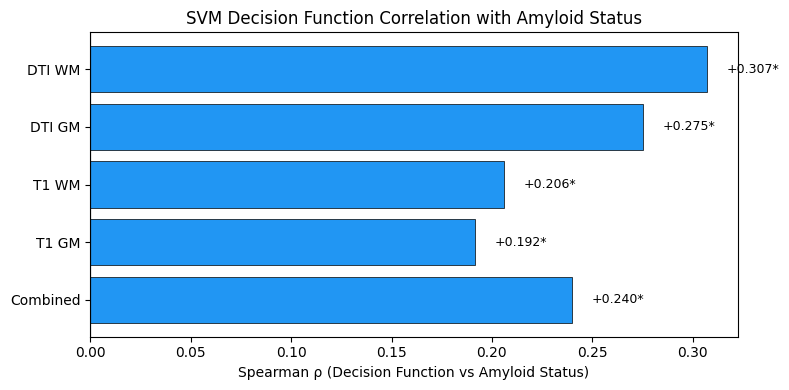

In [ ]:
names = list(corr_results.keys())
rhos = [corr_results[n][0] for n in names]
pvals = [corr_results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2196F3' if p < 0.05 else '#BDBDBD' for p in pvals]
bars = ax.barh(names, rhos, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Spearman ρ (Decision Function vs Amyloid Status)')
ax.set_title('SVM Decision Function Correlation with Amyloid Status')
ax.axvline(0, color='black', linewidth=0.8)

for bar, rho, p in zip(bars, rhos, pvals):
    label = f'{rho:+.3f}{"*" if p < 0.05 else ""}'
    x_pos = rho + 0.01 if rho >= 0 else rho - 0.01
    ha = 'left' if rho >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, label,
            va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Multi-class SVC: 4 classes from (label, label_amy) -> (0,0), (0,1), (1,0), (1,1)

# Filter features and labels to amyloid subset
amy_dti_files = set(paired_df_amy['dti_file_name'].values)
amy_mask = dti_masked_wm['file_name'].isin(amy_dti_files)

X_amy = X_combined_all[amy_mask]
# Build y_multi: (label, label_amy) -> 0,1,2,3
dti_to_amy = paired_df_amy.set_index('dti_file_name')
rows_amy = dti_masked_wm.loc[amy_mask]
y_label = np.array([dti_to_amy.loc[row['file_name'], 'label'] for _, row in rows_amy.iterrows()]).astype(int)
y_amy_num = pd.to_numeric([dti_to_amy.loc[row['file_name'], 'label_amy'] for _, row in rows_amy.iterrows()], errors='coerce').astype(int)
y_multi = y_label * 2 + y_amy_num

In [ ]:
# Class counts
for c in range(4):
    lb, am = [(0,0),(0,1),(1,0),(1,1)][c]
    n = (y_multi == c).sum()
    print(f"Class {c} (label={lb}, amy={am}): n={n}")
print()

# Train-test split and multi-class SVC
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_amy, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

svm_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_multi.fit(X_train_m, y_train_m)
y_pred_m = svm_multi.predict(X_test_m)

acc_multi = balanced_accuracy_score(y_test_m, y_pred_m)
print(f"Multi-class balanced accuracy: {acc_multi:.4f}")
print("Classes: (0,0)=CN amy-, (0,1)=CN amy+, (1,0)=AD amy-, (1,1)=AD amy+")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_m, labels=[0, 1, 2, 3]))

Class 0 (label=0, amy=0): n=94
Class 1 (label=0, amy=1): n=18
Class 2 (label=1, amy=0): n=56
Class 3 (label=1, amy=1): n=32

Multi-class balanced accuracy: 0.6256
Classes: (0,0)=CN amy-, (0,1)=CN amy+, (1,0)=AD amy-, (1,1)=AD amy+
Confusion matrix:
[[13  3  0  3]
 [ 1  2  1  0]
 [ 2  0  9  0]
 [ 1  0  2  3]]


In [ ]:
# T1-only pipeline
X_amy_t1 = np.hstack([t1_wm_pca, t1_gm_pca])[amy_mask]
X_t1_train_m, X_t1_test_m, _, _ = train_test_split(
    X_amy_t1, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
svm_t1_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_multi.fit(X_t1_train_m, y_train_m)
y_pred_t1 = svm_t1_multi.predict(X_t1_test_m)
acc_t1 = balanced_accuracy_score(y_test_m, y_pred_t1)
print(f"T1-only - Multi-class balanced accuracy: {acc_t1:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_t1, labels=[0, 1, 2, 3]))
print()

T1-only - Multi-class balanced accuracy: 0.6177
Confusion matrix:
[[16  2  1  0]
 [ 1  3  0  0]
 [ 2  3  6  0]
 [ 3  1  0  2]]



In [ ]:
# DTI-only pipeline
X_amy_dti = np.hstack([dti_wm_pca, dti_gm_pca])[amy_mask]
X_dti_train_m, X_dti_test_m, _, _ = train_test_split(
    X_amy_dti, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
svm_dti_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_multi.fit(X_dti_train_m, y_train_m)
y_pred_dti = svm_dti_multi.predict(X_dti_test_m)
acc_dti = balanced_accuracy_score(y_test_m, y_pred_dti)
print(f"DTI-only - Multi-class balanced accuracy: {acc_dti:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_dti, labels=[0, 1, 2, 3]))

DTI-only - Multi-class balanced accuracy: 0.6031
Confusion matrix:
[[11  5  3  0]
 [ 0  2  2  0]
 [ 0  0 11  0]
 [ 0  0  4  2]]
